# Explore a bit more in depth the MLRSNet data

Specifically & importantly **whether it is fit for our purpose**


In [1]:
# re-loads code before cell execution, so if sth changes it will propagate:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib import colormaps
from torchvision import transforms

sys.path.append('..')

import src.plotting as splot
import src.data_utils as sduti

In [3]:
images_path = '../data/MLRSNet/'
labels_path = '../../MLRSNet-master/labels/'
label_files = [x for x in os.listdir( labels_path) if x.endswith('.csv')]

# that is the transformations used in DEAR when reading in the data:
tr_pipe = transforms.Compose([transforms.Resize((64,64)),transforms.ToTensor()])

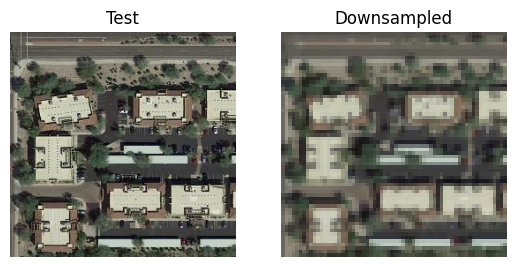

In [6]:
image = sduti.load_image('../data/MLRSNet-subset/dense_residential_area_00001.jpg')
image_tr = sduti.to_numpy( tr_pipe( image))
splot.plot_side_by_side( image, image_tr, title= 'Test')

In [7]:
images_path = '../data/MLRSNet/'
labels_path = '../../MLRSNet-master/labels/'
label_files = [x for x in os.listdir( labels_path) if x.endswith('.csv')]

In [8]:
df = None
dfg = None
for file in label_files:
    df_ = pd.read_csv( f'{labels_path}{file}')
    df_['B_R_C'] = df_.apply( lambda x: f'{x.buildings}{x.road}{x.cars}', axis= 1)
    df = pd.concat([df,df_])
    try:
        dfg = dfg.merge(
            df_.groupby('B_R_C').count()[['image']].rename(columns={'image':file.replace('.csv','')}),
            left_index= True, right_index= True, how= 'outer'
        )
    except AttributeError:
        print(file)
        dfg = df_.groupby('B_R_C').count()[['image']].rename(columns={'image':file.replace('.csv','')})
df['category'] = df['image'].apply( lambda x: '_'.join( x.split('_')[:-1]))

airplane.csv


<Axes: ylabel='B_R_C'>

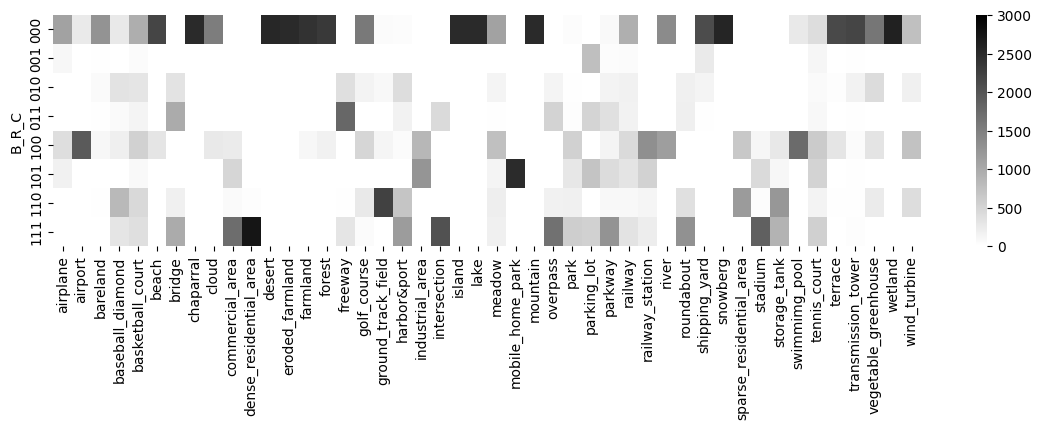

In [9]:
_, ax = plt.subplots( figsize= (14,3))
sns.heatmap(dfg, cmap=colormaps['grey'].reversed(),vmin=0,vmax=3000)

In [10]:
len(df), len(dfg.T)

(109161, 46)

In [11]:
df.groupby('category').agg({'buildings':'sum','road':'sum','cars':'sum'}).head(3)

,buildings,road,cars
category,,,
airplane,560,0,268
airport,1939,0,0
bareland,132,97,42


In [12]:
ims_with_cars = df.loc[df['cars']==1,'image'].tolist()

In [13]:
selected = [x for x in ims_with_cars if x.startswith('meadow')]

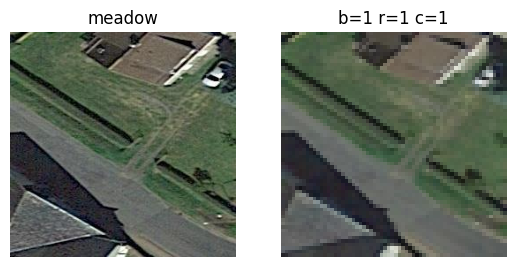

In [14]:
which = 2
fname = selected[ which]
im_fpath = f'{images_path}{fname}'
image = sduti.load_image( im_fpath)
image_tr = sduti.to_numpy( tr_pipe( image))
cat, annot = df.loc[
    df.image==fname, ['category','B_R_C']
].values.reshape(-1).tolist()
annot_str = ' '.join([f'{x}={y}' for x, y in zip('brc',annot)])
splot.plot_side_by_side( image, image_tr, [cat, annot_str])

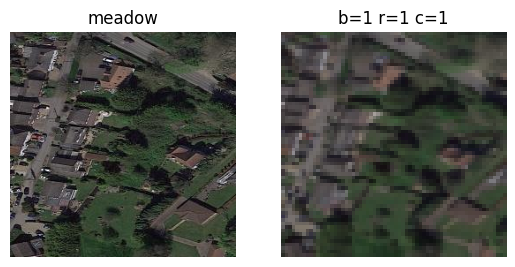

In [15]:
which = 3
fname = selected[ which]
im_fpath = f'{images_path}{fname}'
image = sduti.load_image( im_fpath)
image_tr = sduti.to_numpy( tr_pipe( image))
cat, annot = df.loc[
    df.image==fname, ['category','B_R_C']
].values.reshape(-1).tolist()
annot_str = ' '.join([f'{x}={y}' for x, y in zip('brc',annot)])
splot.plot_side_by_side( image, image_tr, [cat, annot_str])